In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================
# CELL 1: Mount Google Drive & Setup
# ============================================
# Create workspace
!mkdir -p /content/ensemble_leaf_classification
!mkdir -p /content/ensemble_leaf_classification/checkpoints
!mkdir -p /content/ensemble_leaf_classification/logs

import os
os.chdir('/content/ensemble_leaf_classification')

print("✓ Workspace created")

✓ Workspace created


In [3]:
# ============================================
# CELL 2: Install Dependencies
# ============================================
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q opencv-python-headless pillow numpy pandas scikit-learn tqdm matplotlib seaborn gspread google-auth

print("✓ All packages installed")

✓ All packages installed


In [4]:
# ============================================
# CELL 3: Configuration
# ============================================
import torch
import numpy as np
import random

class Config:
    # Paths
    IMAGE_DATASET_PATH = "/content/drive/MyDrive/Refine_Dataset"  # CHANGE THIS
    #GOOGLE_SHEET_NAME = "Leaf_Measurements"  # Your Google Sheet name
    #GOOGLE_SHEET_RANGE = "Sheet1!A:C"  # Columns: Class, Length, Width

    # Model parameters
    NUM_CLASSES = 30
    INPUT_SIZE = 224
    BATCH_SIZE = 64
    NUM_EPOCHS_IMAGE = 100
    LEARNING_RATE_IMAGE = 0.001

    # Numerical model parameters
    NUMERICAL_FEATURES = 2  # Length and Width
    NUMERICAL_HIDDEN_SIZE = [16, 32, 16]  # MLP hidden layers

    # Ensemble parameters
    IMAGE_WEIGHT = 0.5  # Weight for image model (0-1)
    NUMERICAL_WEIGHT = 0.5  # Weight for numerical model (1 - IMAGE_WEIGHT)

    # Training
    NUM_WORKERS = 2
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42

    # Checkpointing
    SAVE_DIR = "/content/ensemble_leaf_classification/checkpoints"

    def __init__(self):
        # Ensure weights sum to 1
        assert abs(self.IMAGE_WEIGHT + self.NUMERICAL_WEIGHT - 1.0) < 1e-6, "Weights must sum to 1"

config = Config()

# Set seed
random.seed(config.SEED)
np.random.seed(config.SEED)
torch.manual_seed(config.SEED)

print(f"✓ Configuration loaded")
print(f"✓ Device: {config.DEVICE}")
print(f"✓ Ensemble weights: Image={config.IMAGE_WEIGHT}, Numerical={config.NUMERICAL_WEIGHT}")

✓ Configuration loaded
✓ Device: cuda
✓ Ensemble weights: Image=0.5, Numerical=0.5


In [5]:
# ============================================
# CELL 4 (UPDATED): Load Numerical Data (100 rows per class)
# ============================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from google.colab import files
from sklearn.model_selection import train_test_split

def load_numerical_data_from_csv():
    """Load length and width data (100 rows per species)"""

    print("📁 Please upload your leaf_measurements.csv file")
    print("CSV should have 3000 rows (100 per species) with columns: Class, Length, Width")

    uploaded = files.upload()

    for filename in uploaded.keys():
        df = pd.read_csv(filename)
        print(f"✓ Loaded {filename}")
        print(f"   Total rows: {len(df)}")
        break

    # Verify columns
    required_columns = ['Class', 'Length', 'Width']
    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    # Check rows per class
    rows_per_class = df.groupby('Class').size()
    print(f"\n📊 Rows per species:")
    for species, count in rows_per_class.items():
        print(f"   {species}: {count} rows")

    # Create features and labels
    class_names = df['Class'].values
    lengths = df['Length'].astype(float).values
    widths = df['Width'].astype(float).values

    # Create feature matrix
    numerical_features = np.column_stack([lengths, widths])

    # Create label mapping
    unique_classes = df['Class'].unique()
    class_to_idx = {cls: idx for idx, cls in enumerate(unique_classes)}
    labels = np.array([class_to_idx[cls] for cls in class_names])

    # Standardize features
    scaler = StandardScaler()
    numerical_features_scaled = scaler.fit_transform(numerical_features)

    print(f"\n✓ Numerical data loaded:")
    print(f"   Total samples: {len(numerical_features_scaled)}")
    print(f"   Number of species: {len(unique_classes)}")
    print(f"   Features per sample: {numerical_features_scaled.shape[1]} (Length, Width)")
    print(f"   Features shape: {numerical_features_scaled.shape}")
    print(f"   Labels shape: {labels.shape}")

    # Show statistics
    print(f"\n📊 Feature statistics (original scale):")
    print(f"   Length - Mean: {lengths.mean():.2f}cm, Std: {lengths.std():.2f}cm")
    print(f"   Width  - Mean: {widths.mean():.2f}cm, Std: {widths.std():.2f}cm")

    return numerical_features_scaled, labels, class_to_idx, scaler, df

# Load data
numerical_features, numerical_labels, class_to_idx, scaler, df = load_numerical_data_from_csv()

# Split numerical data for training (will be matched with images)
print(f"\n✓ Class mapping created for {len(class_to_idx)} species")
print(f"   Example mapping: {list(class_to_idx.items())[:5]}")

📁 Please upload your leaf_measurements.csv file
CSV should have 3000 rows (100 per species) with columns: Class, Length, Width


Saving Updated with augmented data Numeric_Medicinal_Plant_Data.csv to Updated with augmented data Numeric_Medicinal_Plant_Data.csv
✓ Loaded Updated with augmented data Numeric_Medicinal_Plant_Data.csv
   Total rows: 300

📊 Rows per species:
   1.Tulshi: 10 rows
   10.Jolpai: 10 rows
   11.Neem: 10 rows
   12.Joba: 10 rows
   13.Telakucha: 10 rows
   14.Noyontara: 10 rows
   15.Bongada: 10 rows
   16.Boroi: 10 rows
   17.Horitoki: 10 rows
   18.Mehedi: 10 rows
   19.Aorhor: 10 rows
   2.Pathorkuchi: 10 rows
   20.Pudina: 10 rows
   21.Thankuni: 10 rows
   22.Paharipata: 10 rows
   23.Lemon: 10 rows
   24.Dhutra: 10 rows
   25.Raktapata: 10 rows
   26.Akondo: 10 rows
   27.Karipata: 10 rows
   28.Oporajita: 10 rows
   29.Hasnahena: 10 rows
   3.Bashok: 10 rows
   30.Orjun: 10 rows
   4.Hatishur: 10 rows
   5.Goolmorich: 10 rows
   6.Togor: 10 rows
   7.Daruchini: 10 rows
   8.Tejpata: 10 rows
   9.Sofeda: 10 rows

✓ Numerical data loaded:
   Total samples: 300
   Number of species: 30
 

In [6]:
# ============================================
# CELL 5 (UPDATED): Image Dataset with Matching Numerical Features
# ============================================
import cv2
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
import pandas as pd

class LeafDatasetWithNumerical(Dataset):
    """Dataset that matches each image with its corresponding numerical features"""

    def __init__(self, root_dir, numerical_df, class_to_idx, is_train=True):
        self.root_dir = root_dir
        self.numerical_df = numerical_df
        self.class_to_idx = class_to_idx
        self.is_train = is_train

        # Create reverse mapping
        self.idx_to_class = {v: k for k, v in class_to_idx.items()}

        # Load all image paths with their numerical features
        self.samples = []
        self._load_samples()

        # Setup transforms
        if is_train:
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(config.INPUT_SIZE, scale=(0.6, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(20),
                transforms.ColorJitter(brightness=0.2, contrast=0.3),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((config.INPUT_SIZE, config.INPUT_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])

    def _load_samples(self):
        """Load all images and match with numerical features from the same class"""

        # Get all class folders
        class_folders = [d for d in os.listdir(self.root_dir)
                        if os.path.isdir(os.path.join(self.root_dir, d))]

        for class_name in class_folders:
            if class_name not in self.class_to_idx:
                print(f"⚠️ Warning: {class_name} not in numerical data, skipping")
                continue

            class_idx = self.class_to_idx[class_name]
            class_path = os.path.join(self.root_dir, class_name)

            # Get all numerical samples for this class
            class_numerical_data = self.numerical_df[self.numerical_df['Class'] == class_name]

            # Get all images in this class folder
            images = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            print(f"   {class_name}: {len(images)} images, {len(class_numerical_data)} numerical samples")

            # Match each image with a numerical sample (cycle if more images than numerical samples)
            for img_idx, img_file in enumerate(images):
                img_path = os.path.join(class_path, img_file)

                # Get corresponding numerical sample (cycle through available samples)
                numerical_idx = img_idx % len(class_numerical_data)
                numerical_sample = class_numerical_data.iloc[numerical_idx]

                numerical_features = np.array([
                    numerical_sample['Length'],
                    numerical_sample['Width']
                ])

                self.samples.append({
                    'image_path': img_path,
                    'label': class_idx,
                    'numerical_features': numerical_features
                })

        print(f"\n✓ Loaded {len(self.samples)} image-numerical pairs")

        # Verify counts
        labels_count = pd.Series([s['label'] for s in self.samples]).value_counts()
        print(f"   Samples per class: {dict(sorted(labels_count.items()))}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Load and transform image
        image = Image.open(sample['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Get numerical features
        numerical_feat = torch.tensor(sample['numerical_features'], dtype=torch.float32)

        # Get label
        label = sample['label']

        return image, numerical_feat, label

def create_dataloaders():
    """Create train, validation, and test dataloaders"""

    # Check if data is already split
    train_path = os.path.join(config.IMAGE_DATASET_PATH, 'train')
    val_path = os.path.join(config.IMAGE_DATASET_PATH, 'val')
    test_path = os.path.join(config.IMAGE_DATASET_PATH, 'test')

    if os.path.exists(train_path) and os.path.exists(val_path):
        print("📁 Using existing train/val/test split")
        train_dataset = LeafDatasetWithNumerical(train_path, df, class_to_idx, is_train=True)
        val_dataset = LeafDatasetWithNumerical(val_path, df, class_to_idx, is_train=False)
        test_dataset = LeafDatasetWithNumerical(test_path, df, class_to_idx, is_train=False)
    else:
        print("📁 Creating train/val/test split (60/25/15)")
        # Load all samples
        full_dataset = LeafDatasetWithNumerical(config.IMAGE_DATASET_PATH, df, class_to_idx, is_train=True)

        # Split indices
        total_size = len(full_dataset)
        train_size = int(0.6 * total_size)
        val_size = int(0.25 * total_size)
        test_size = total_size - train_size - val_size

        train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
            full_dataset, [train_size, val_size, test_size]
        )
        print(f"   Train: {train_size}, Val: {val_size}, Test: {test_size}")

    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True,
                              num_workers=config.NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                            num_workers=config.NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                             num_workers=config.NUM_WORKERS, pin_memory=True)

    return train_loader, val_loader, test_loader

# Create dataloaders
print("\n📊 Creating dataloaders...")
train_loader, val_loader, test_loader = create_dataloaders()


📊 Creating dataloaders...
📁 Creating train/val/test split (60/25/15)
   9.Sofeda: 100 images, 10 numerical samples
   7.Daruchini: 100 images, 10 numerical samples
   8.Tejpata: 100 images, 10 numerical samples
   5.Goolmorich: 100 images, 10 numerical samples
   4.Hatishur: 100 images, 10 numerical samples
   6.Togor: 100 images, 10 numerical samples
   30.Orjun: 100 images, 10 numerical samples
   3.Bashok: 100 images, 10 numerical samples
   29.Hasnahena: 100 images, 10 numerical samples
   26.Akondo: 100 images, 10 numerical samples
   27.Karipata: 100 images, 10 numerical samples
   28.Oporajita: 100 images, 10 numerical samples
   25.Raktapata: 100 images, 10 numerical samples
   23.Lemon: 100 images, 10 numerical samples
   24.Dhutra: 100 images, 10 numerical samples
   22.Paharipata: 100 images, 10 numerical samples
   21.Thankuni: 100 images, 10 numerical samples
   19.Aorhor: 100 images, 10 numerical samples
   18.Mehedi: 100 images, 10 numerical samples
   20.Pudina: 100 im

In [7]:
# ============================================
# CELL 6: Texture-Only Image Model (ResNet50 Layers 1&2)
# ============================================
import torch.nn as nn
import torchvision.models as models

class TextureOnlyImageModel(nn.Module):
    """ResNet50 using only layers 1&2 for texture features"""

    def __init__(self, num_classes=30):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Take only first 2 layers (texture detectors)
        self.texture_features = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
        )

        # Global pooling and classifier
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(512, num_classes)  # 512 from layer2

    def forward(self, x):
        # Extract texture features
        features = self.texture_features(x)
        pooled = self.pool(features)
        flattened = pooled.flatten(1)
        output = self.classifier(flattened)
        return output

# Initialize image model
image_model = TextureOnlyImageModel(num_classes=config.NUM_CLASSES)
image_model = image_model.to(config.DEVICE)

print("✓ Texture-Only Image Model Ready")
print(f"   Total parameters: {sum(p.numel() for p in image_model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s]


✓ Texture-Only Image Model Ready
   Total parameters: 1,460,318


In [8]:
# ============================================
# CELL 7 (RANDOM FOREST VERSION): Numerical Model
# ============================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import joblib

class NumericalRandomForest:
    """Random Forest wrapper for numerical features"""

    def __init__(self, n_estimators=100, max_depth=10, random_state=42):
        self.model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_state,
            n_jobs=-1
        )
        self.is_fitted = False

    def fit(self, X, y):
        self.model.fit(X, y)
        self.is_fitted = True
        print(f"✓ Random Forest trained with {self.model.n_estimators} trees")

    def predict_proba(self, X):
        if not self.is_fitted:
            raise ValueError("Model not fitted yet")
        return self.model.predict_proba(X)

    def predict(self, X):
        if not self.is_fitted:
            raise ValueError("Model not fitted yet")
        return self.model.predict(X)

    def save(self, path):
        joblib.dump(self.model, path)

    def load(self, path):
        self.model = joblib.load(path)
        self.is_fitted = True

# Initialize Random Forest
numerical_model = NumericalRandomForest(
    n_estimators=100,
    max_depth=10,
    random_state=config.SEED
)
print("✓ Random Forest Model Ready")

✓ Random Forest Model Ready



🌲 Training Random Forest on numerical data...
   Training samples: 1800
   Features shape: (1800, 2)
✓ Random Forest trained with 100 trees
   Random Forest validation accuracy: 98.00%

🚀 Training Ensemble (Image + Random Forest)
Device: cuda
Epochs: 100
Ensemble weights: Image=0.5, RF=0.5



Epoch 1/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.42it/s]


🎉 New best validation accuracy: 96.53%

📊 Epoch 1/100
   Train - Loss: 3.1931, Acc: 0.15%
   Val - Image: 15.20%, RF: 98.00%, Ensemble: 96.53%
   Best Ensemble Val Acc: 96.53%



Epoch 2/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.41it/s]



📊 Epoch 2/100
   Train - Loss: 2.7606, Acc: 0.25%
   Val - Image: 16.00%, RF: 98.00%, Ensemble: 94.53%
   Best Ensemble Val Acc: 96.53%



...


📊 Epoch 8/100
   Train - Loss: 1.6179, Acc: 0.53%
   Val - Image: 25.47%, RF: 98.00%, Ensemble: 95.73%
   Best Ensemble Val Acc: 97.07%



Epoch 9/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.41it/s]



📊 Epoch 9/100
   Train - Loss: 1.5877, Acc: 0.54%
   Val - Image: 9.33%, RF: 98.00%, Ensemble: 42.00%
   Best Ensemble Val Acc: 97.07%



Epoch 10/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.81it/s]


🎉 New best validation accuracy: 97.47%

📊 Epoch 10/100
   Train - Loss: 1.5287, Acc: 0.53%
   Val - Image: 35.20%, RF: 98.00%, Ensemble: 97.47%
   Best Ensemble Val Acc: 97.47%



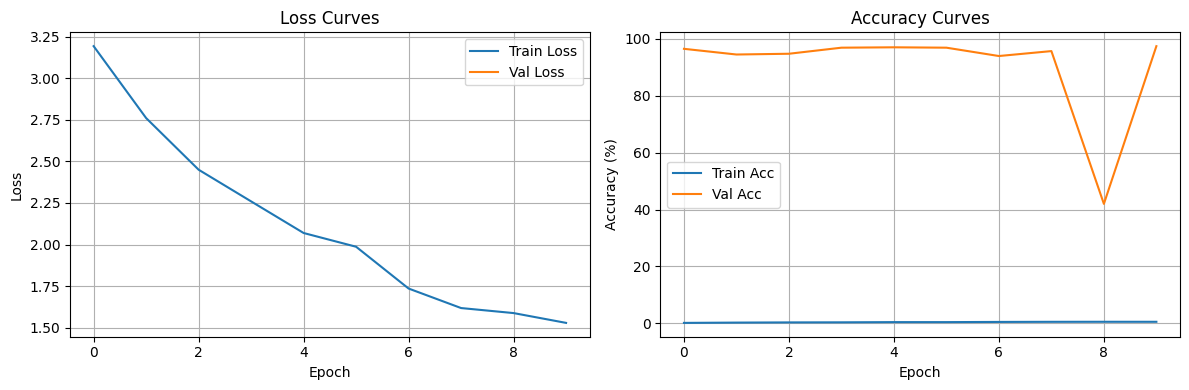

Epoch 11/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.72it/s]



📊 Epoch 11/100
   Train - Loss: 1.3779, Acc: 0.59%
   Val - Image: 44.93%, RF: 98.00%, Ensemble: 96.93%
   Best Ensemble Val Acc: 97.47%



Epoch 12/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.85it/s]



📊 Epoch 12/100
   Train - Loss: 1.2831, Acc: 0.60%
   Val - Image: 36.53%, RF: 98.00%, Ensemble: 94.00%
   Best Ensemble Val Acc: 97.47%



Epoch 13/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.80it/s]


...


📊 Epoch 18/100
   Train - Loss: 1.0571, Acc: 0.68%
   Val - Image: 52.00%, RF: 98.00%, Ensemble: 95.87%
   Best Ensemble Val Acc: 97.47%



Epoch 19/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.85it/s]



📊 Epoch 19/100
   Train - Loss: 0.9427, Acc: 0.71%
   Val - Image: 45.73%, RF: 98.00%, Ensemble: 94.00%
   Best Ensemble Val Acc: 97.47%



Epoch 20/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.83it/s]



📊 Epoch 20/100
   Train - Loss: 0.8187, Acc: 0.77%
   Val - Image: 61.07%, RF: 98.00%, Ensemble: 96.13%
   Best Ensemble Val Acc: 97.47%



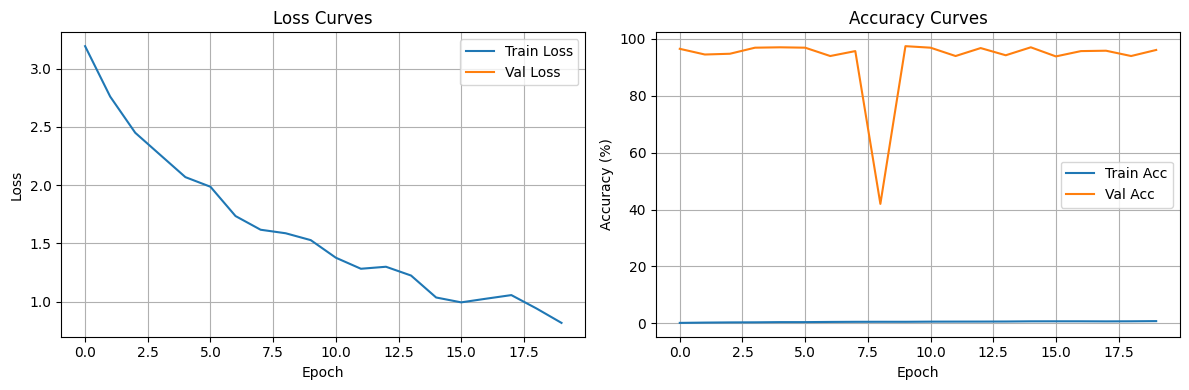

Epoch 21/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.46it/s]



📊 Epoch 21/100
   Train - Loss: 0.7900, Acc: 0.77%
   Val - Image: 52.00%, RF: 98.00%, Ensemble: 90.00%
   Best Ensemble Val Acc: 97.47%



Epoch 22/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.37it/s]



📊 Epoch 22/100
   Train - Loss: 0.8044, Acc: 0.76%
   Val - Image: 54.80%, RF: 98.00%, Ensemble: 94.27%
   Best Ensemble Val Acc: 97.47%



Epoch 23/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.39it/s]


...


📊 Epoch 28/100
   Train - Loss: 0.5188, Acc: 0.85%
   Val - Image: 55.87%, RF: 98.00%, Ensemble: 94.67%
   Best Ensemble Val Acc: 97.47%



Epoch 29/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.42it/s]



📊 Epoch 29/100
   Train - Loss: 0.5279, Acc: 0.86%
   Val - Image: 42.00%, RF: 98.00%, Ensemble: 83.60%
   Best Ensemble Val Acc: 97.47%



Epoch 30/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.38it/s]



📊 Epoch 30/100
   Train - Loss: 0.5823, Acc: 0.83%
   Val - Image: 63.47%, RF: 98.00%, Ensemble: 91.73%
   Best Ensemble Val Acc: 97.47%



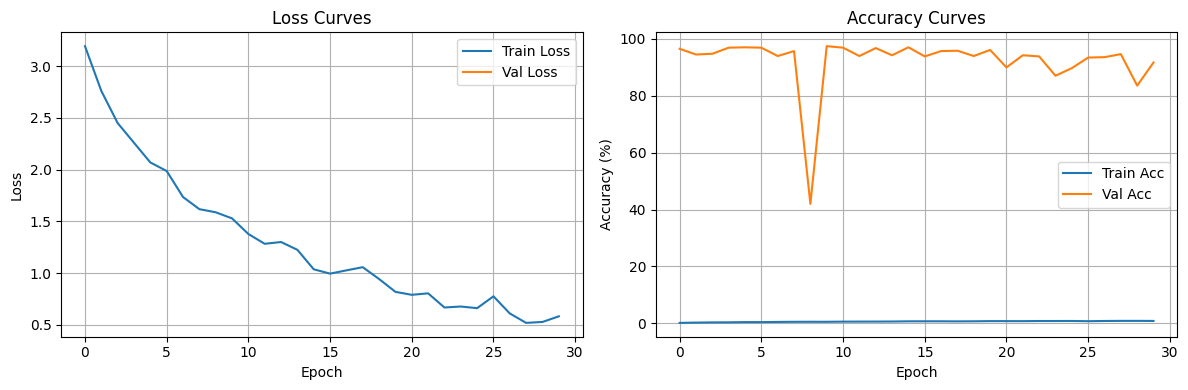

Epoch 31/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.41it/s]



📊 Epoch 31/100
   Train - Loss: 0.4796, Acc: 0.86%
   Val - Image: 66.67%, RF: 98.00%, Ensemble: 96.13%
   Best Ensemble Val Acc: 97.47%



Epoch 32/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.46it/s]



📊 Epoch 32/100
   Train - Loss: 0.5544, Acc: 0.86%
   Val - Image: 31.60%, RF: 98.00%, Ensemble: 78.00%
   Best Ensemble Val Acc: 97.47%



Epoch 33/100 [Val]: 100%|██████████| 12/12 [00:07<00:00,  1.65it/s]


...


📊 Epoch 38/100
   Train - Loss: 0.3363, Acc: 0.92%
   Val - Image: 80.93%, RF: 98.00%, Ensemble: 97.20%
   Best Ensemble Val Acc: 97.47%



Epoch 39/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.36it/s]



📊 Epoch 39/100
   Train - Loss: 0.5380, Acc: 0.84%
   Val - Image: 63.47%, RF: 98.00%, Ensemble: 89.20%
   Best Ensemble Val Acc: 97.47%



Epoch 40/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.36it/s]



📊 Epoch 40/100
   Train - Loss: 0.4796, Acc: 0.86%
   Val - Image: 76.40%, RF: 98.00%, Ensemble: 96.27%
   Best Ensemble Val Acc: 97.47%



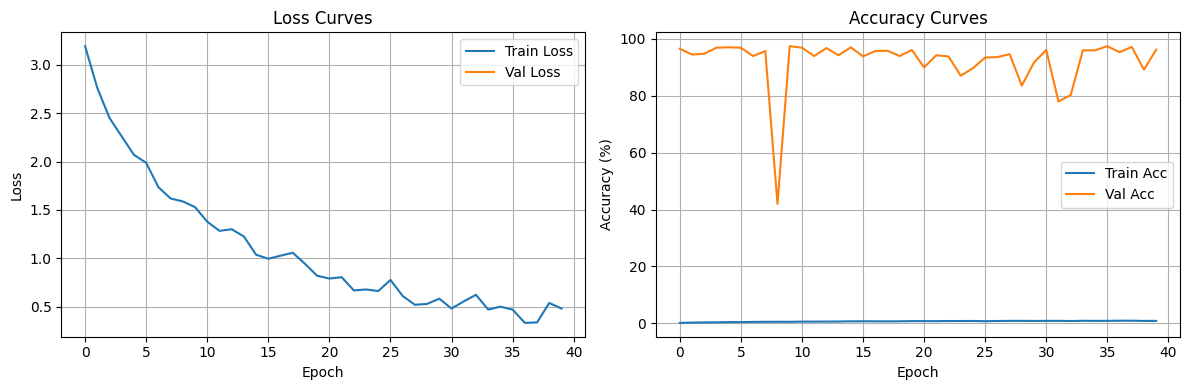

Epoch 41/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.45it/s]


🎉 New best validation accuracy: 98.27%

📊 Epoch 41/100
   Train - Loss: 0.3537, Acc: 0.90%
   Val - Image: 82.53%, RF: 98.00%, Ensemble: 98.27%
   Best Ensemble Val Acc: 98.27%



Epoch 42/100 [Val]: 100%|██████████| 12/12 [00:07<00:00,  1.60it/s]



📊 Epoch 42/100
   Train - Loss: 0.3436, Acc: 0.90%
   Val - Image: 83.07%, RF: 98.00%, Ensemble: 97.07%
   Best Ensemble Val Acc: 98.27%



Epoch 43/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.73it/s]


...


📊 Epoch 48/100
   Train - Loss: 0.2573, Acc: 0.93%
   Val - Image: 65.20%, RF: 98.00%, Ensemble: 83.87%
   Best Ensemble Val Acc: 98.27%



Epoch 49/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.42it/s]



📊 Epoch 49/100
   Train - Loss: 0.2997, Acc: 0.91%
   Val - Image: 60.80%, RF: 98.00%, Ensemble: 90.00%
   Best Ensemble Val Acc: 98.27%



Epoch 50/100 [Val]: 100%|██████████| 12/12 [00:07<00:00,  1.71it/s]



📊 Epoch 50/100
   Train - Loss: 0.3071, Acc: 0.91%
   Val - Image: 71.20%, RF: 98.00%, Ensemble: 91.73%
   Best Ensemble Val Acc: 98.27%



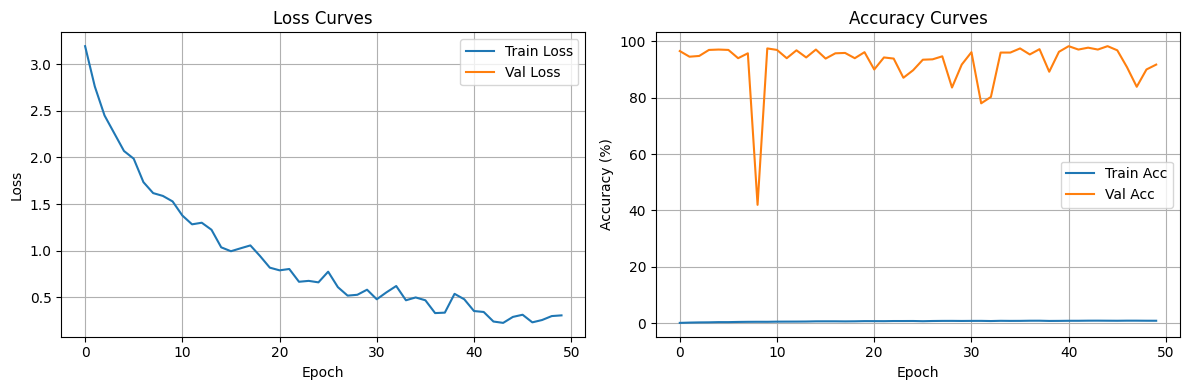

Epoch 51/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.79it/s]



📊 Epoch 51/100
   Train - Loss: 0.3306, Acc: 0.91%
   Val - Image: 85.73%, RF: 98.00%, Ensemble: 98.00%
   Best Ensemble Val Acc: 98.27%



Epoch 52/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.81it/s]



📊 Epoch 52/100
   Train - Loss: 0.3644, Acc: 0.89%
   Val - Image: 66.53%, RF: 98.00%, Ensemble: 91.20%
   Best Ensemble Val Acc: 98.27%



Epoch 53/100 [Val]: 100%|██████████| 12/12 [00:07<00:00,  1.64it/s]


...

🎉 New best validation accuracy: 98.40%

📊 Epoch 58/100
   Train - Loss: 0.2135, Acc: 0.94%
   Val - Image: 89.87%, RF: 98.00%, Ensemble: 98.40%
   Best Ensemble Val Acc: 98.40%



Epoch 59/100 [Val]: 100%|██████████| 12/12 [00:07<00:00,  1.70it/s]



📊 Epoch 59/100
   Train - Loss: 0.1836, Acc: 0.96%
   Val - Image: 80.40%, RF: 98.00%, Ensemble: 97.47%
   Best Ensemble Val Acc: 98.40%



Epoch 60/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.80it/s]



📊 Epoch 60/100
   Train - Loss: 0.1848, Acc: 0.95%
   Val - Image: 83.60%, RF: 98.00%, Ensemble: 96.67%
   Best Ensemble Val Acc: 98.40%



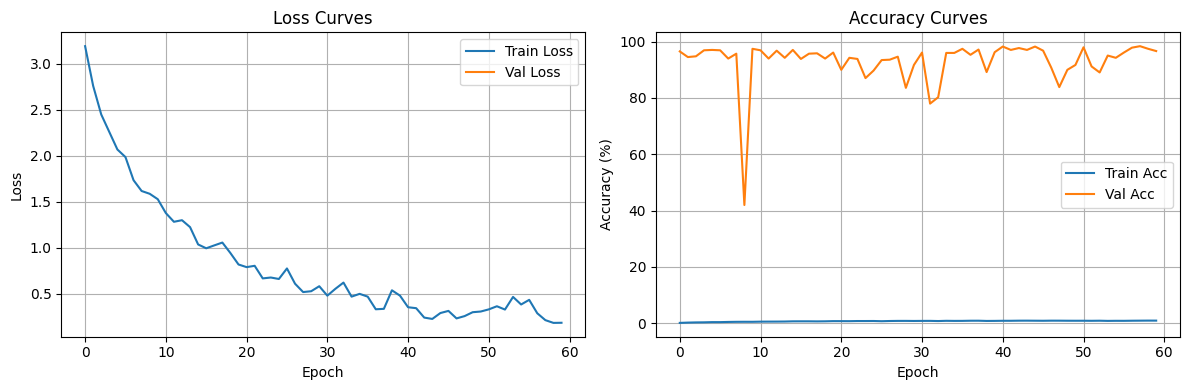

Epoch 61/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.85it/s]



📊 Epoch 61/100
   Train - Loss: 0.2213, Acc: 0.94%
   Val - Image: 83.33%, RF: 98.00%, Ensemble: 97.20%
   Best Ensemble Val Acc: 98.40%



Epoch 62/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.79it/s]



📊 Epoch 62/100
   Train - Loss: 0.1990, Acc: 0.94%
   Val - Image: 88.00%, RF: 98.00%, Ensemble: 98.27%
   Best Ensemble Val Acc: 98.40%



Epoch 63/100 [Val]: 100%|██████████| 12/12 [00:07<00:00,  1.57it/s]


...


📊 Epoch 68/100
   Train - Loss: 0.1902, Acc: 0.96%
   Val - Image: 87.47%, RF: 98.00%, Ensemble: 96.27%
   Best Ensemble Val Acc: 98.53%



Epoch 69/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.80it/s]



📊 Epoch 69/100
   Train - Loss: 0.4071, Acc: 0.88%
   Val - Image: 68.13%, RF: 98.00%, Ensemble: 92.00%
   Best Ensemble Val Acc: 98.53%



Epoch 70/100 [Val]: 100%|██████████| 12/12 [00:07<00:00,  1.66it/s]



📊 Epoch 70/100
   Train - Loss: 0.2286, Acc: 0.94%
   Val - Image: 74.93%, RF: 98.00%, Ensemble: 92.53%
   Best Ensemble Val Acc: 98.53%



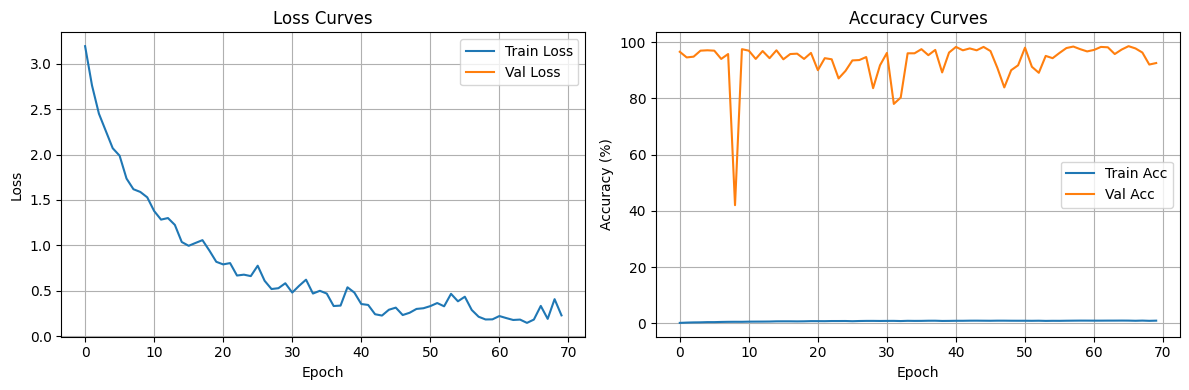

Epoch 71/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.46it/s]



📊 Epoch 71/100
   Train - Loss: 0.2076, Acc: 0.94%
   Val - Image: 64.67%, RF: 98.00%, Ensemble: 90.27%
   Best Ensemble Val Acc: 98.53%



Epoch 72/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.35it/s]



📊 Epoch 72/100
   Train - Loss: 0.1634, Acc: 0.96%
   Val - Image: 92.53%, RF: 98.00%, Ensemble: 98.27%
   Best Ensemble Val Acc: 98.53%



Epoch 73/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.38it/s]


...


📊 Epoch 78/100
   Train - Loss: 0.3366, Acc: 0.92%
   Val - Image: 84.40%, RF: 98.00%, Ensemble: 96.53%
   Best Ensemble Val Acc: 99.07%



Epoch 79/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.48it/s]



📊 Epoch 79/100
   Train - Loss: 0.3028, Acc: 0.91%
   Val - Image: 80.40%, RF: 98.00%, Ensemble: 96.53%
   Best Ensemble Val Acc: 99.07%



Epoch 80/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.39it/s]



📊 Epoch 80/100
   Train - Loss: 0.1695, Acc: 0.95%
   Val - Image: 92.00%, RF: 98.00%, Ensemble: 98.93%
   Best Ensemble Val Acc: 99.07%



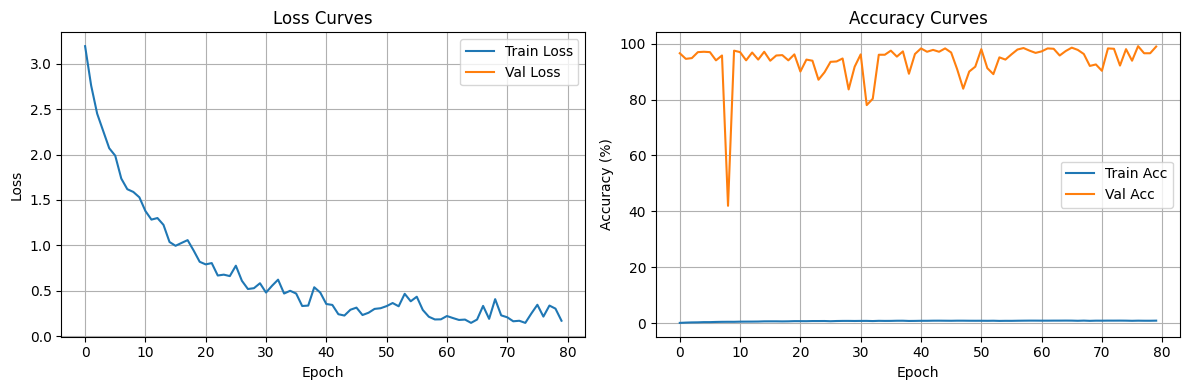

Epoch 81/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.38it/s]


🎉 New best validation accuracy: 99.47%

📊 Epoch 81/100
   Train - Loss: 0.1146, Acc: 0.97%
   Val - Image: 95.20%, RF: 98.00%, Ensemble: 99.47%
   Best Ensemble Val Acc: 99.47%



Epoch 82/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.42it/s]



📊 Epoch 82/100
   Train - Loss: 0.0874, Acc: 0.98%
   Val - Image: 91.47%, RF: 98.00%, Ensemble: 98.40%
   Best Ensemble Val Acc: 99.47%



Epoch 83/100 [Val]: 100%|██████████| 12/12 [00:07<00:00,  1.64it/s]


...


📊 Epoch 88/100
   Train - Loss: 0.2490, Acc: 0.93%
   Val - Image: 84.93%, RF: 98.00%, Ensemble: 95.33%
   Best Ensemble Val Acc: 99.47%



Epoch 89/100 [Val]: 100%|██████████| 12/12 [00:09<00:00,  1.29it/s]



📊 Epoch 89/100
   Train - Loss: 0.1483, Acc: 0.96%
   Val - Image: 94.13%, RF: 98.00%, Ensemble: 99.33%
   Best Ensemble Val Acc: 99.47%



Epoch 90/100 [Val]: 100%|██████████| 12/12 [00:08<00:00,  1.44it/s]



📊 Epoch 90/100
   Train - Loss: 0.1750, Acc: 0.95%
   Val - Image: 95.07%, RF: 98.00%, Ensemble: 99.07%
   Best Ensemble Val Acc: 99.47%



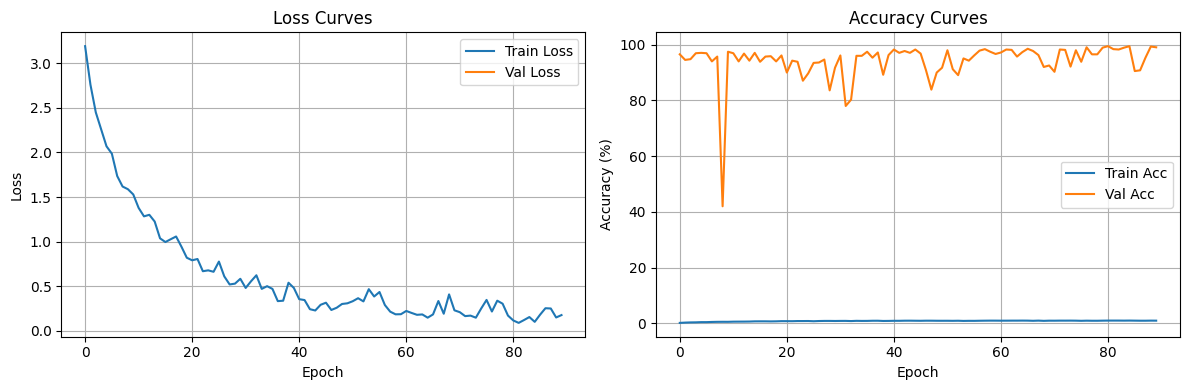

Epoch 91/100 [Val]: 100%|██████████| 12/12 [00:07<00:00,  1.63it/s]



📊 Epoch 91/100
   Train - Loss: 0.1347, Acc: 0.97%
   Val - Image: 93.73%, RF: 98.00%, Ensemble: 98.40%
   Best Ensemble Val Acc: 99.47%



Epoch 92/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.80it/s]



📊 Epoch 92/100
   Train - Loss: 0.1432, Acc: 0.96%
   Val - Image: 94.00%, RF: 98.00%, Ensemble: 99.07%
   Best Ensemble Val Acc: 99.47%



Epoch 93/100 [Val]: 100%|██████████| 12/12 [00:07<00:00,  1.67it/s]


...


📊 Epoch 98/100
   Train - Loss: 0.2836, Acc: 0.93%
   Val - Image: 78.00%, RF: 98.00%, Ensemble: 93.07%
   Best Ensemble Val Acc: 99.47%



Epoch 99/100 [Val]: 100%|██████████| 12/12 [00:07<00:00,  1.52it/s]



📊 Epoch 99/100
   Train - Loss: 0.2641, Acc: 0.92%
   Val - Image: 80.40%, RF: 98.00%, Ensemble: 94.27%
   Best Ensemble Val Acc: 99.47%



Epoch 100/100 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.84it/s]



📊 Epoch 100/100
   Train - Loss: 0.1176, Acc: 0.97%
   Val - Image: 89.87%, RF: 98.00%, Ensemble: 97.60%
   Best Ensemble Val Acc: 99.47%



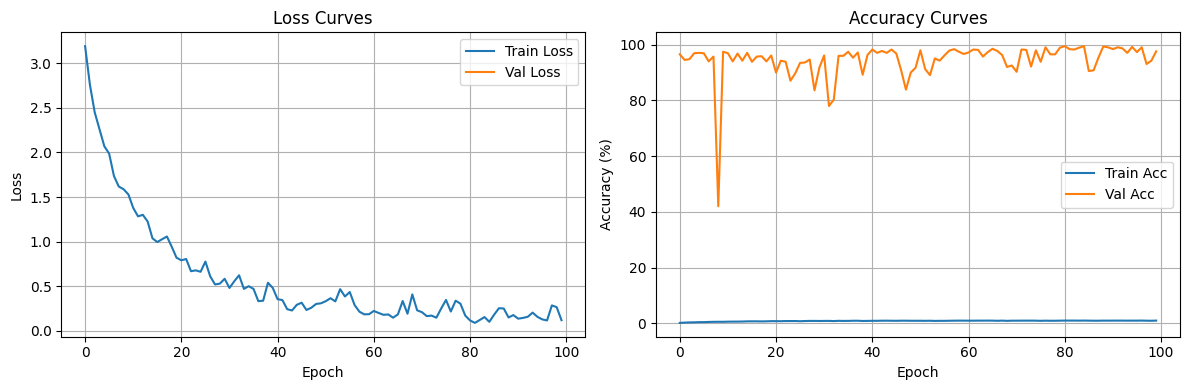


✅ Training Complete!
✓ Best validation accuracy: 99.47%


In [9]:
# ============================================
# CELL 8 (RANDOM FOREST ENSEMBLE): Training
# ============================================
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np

class EnsembleTrainerRF:
    """Trainer for ensemble with Random Forest"""

    def __init__(self, image_model, numerical_model, train_loader, val_loader):
        self.image_model = image_model
        self.numerical_model = numerical_model
        self.train_loader = train_loader
        self.val_loader = val_loader

        # Optimizer for image model only
        self.optimizer = torch.optim.AdamW(
            image_model.parameters(),
            lr=config.LEARNING_RATE_IMAGE,
            weight_decay=1e-4
        )

        self.criterion = nn.CrossEntropyLoss()

        # Metrics
        self.best_val_acc = 0
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []

        # Train Random Forest first
        self._train_random_forest()

    def _train_random_forest(self):
        """Train Random Forest on numerical features"""
        print("\n🌲 Training Random Forest on numerical data...")

        # Collect all numerical features and labels from training set
        X_train = []
        y_train = []

        for _, numerical_feats, labels in self.train_loader:
            X_train.extend(numerical_feats.numpy())
            y_train.extend(labels.numpy())

        X_train = np.array(X_train)
        y_train = np.array(y_train)

        print(f"   Training samples: {len(X_train)}")
        print(f"   Features shape: {X_train.shape}")

        # Train Random Forest
        self.numerical_model.fit(X_train, y_train)

        # Evaluate on validation set
        X_val = []
        y_val = []
        for _, numerical_feats, labels in self.val_loader:
            X_val.extend(numerical_feats.numpy())
            y_val.extend(labels.numpy())

        X_val = np.array(X_val)
        y_val = np.array(y_val)

        val_preds = self.numerical_model.predict(X_val)
        val_acc = accuracy_score(y_val, val_preds) * 100
        print(f"   Random Forest validation accuracy: {val_acc:.2f}%")

    def train_epoch(self, epoch):
        """Train image model for one epoch"""
        self.image_model.train()
        total_loss = 0
        all_preds = []
        all_labels = []

        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch+1}/{config.NUM_EPOCHS_IMAGE} [Train]')
        for images, numerical_feats, labels in pbar:
            images = images.to(config.DEVICE)
            labels = labels.to(config.DEVICE)

            # Zero gradients
            self.optimizer.zero_grad()

            # Forward pass through image model only
            image_outputs = self.image_model(images)
            loss = self.criterion(image_outputs, labels)

            # Backward pass
            loss.backward()
            self.optimizer.step()

            # Metrics
            total_loss += loss.item()
            preds = torch.argmax(image_outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Update progress bar
            current_acc = accuracy_score(all_labels[-32:], all_preds[-32:]) if len(all_preds) >= 32 else 0
            pbar.set_postfix({'loss': loss.item(), 'acc': f'{current_acc:.3f}'})

        avg_loss = total_loss / len(self.train_loader)
        accuracy = accuracy_score(all_labels, all_preds)

        self.train_losses.append(avg_loss)
        self.train_accs.append(accuracy)

        return avg_loss, accuracy

    def validate(self, epoch):
        """Validate ensemble (image + Random Forest)"""
        self.image_model.eval()

        all_ensemble_preds = []
        all_image_preds = []
        all_numerical_preds = []
        all_labels = []

        with torch.no_grad():
            pbar = tqdm(self.val_loader, desc=f'Epoch {epoch+1}/{config.NUM_EPOCHS_IMAGE} [Val]')
            for images, numerical_feats, labels in pbar:
                images = images.to(config.DEVICE)
                labels = labels.to(config.DEVICE)

                # Image model predictions
                image_outputs = self.image_model(images)
                image_probs = torch.softmax(image_outputs, dim=1).cpu().numpy()

                # Random Forest predictions
                numerical_probs = self.numerical_model.predict_proba(numerical_feats.numpy())

                # Ensemble (weighted average)
                ensemble_probs = (config.IMAGE_WEIGHT * image_probs +
                                 config.NUMERICAL_WEIGHT * numerical_probs)
                ensemble_preds = np.argmax(ensemble_probs, axis=1)

                # Individual predictions
                image_preds = np.argmax(image_probs, axis=1)
                numerical_preds = np.argmax(numerical_probs, axis=1)

                all_ensemble_preds.extend(ensemble_preds)
                all_image_preds.extend(image_preds)
                all_numerical_preds.extend(numerical_preds)
                all_labels.extend(labels.cpu().numpy())

        ensemble_acc = accuracy_score(all_labels, all_ensemble_preds) * 100
        image_acc = accuracy_score(all_labels, all_image_preds) * 100
        numerical_acc = accuracy_score(all_labels, all_numerical_preds) * 100

        self.val_accs.append(ensemble_acc)

        return ensemble_acc, image_acc, numerical_acc

    def train(self):
        """Main training loop"""
        print(f"\n{'='*60}")
        print(f"🚀 Training Ensemble (Image + Random Forest)")
        print(f"{'='*60}")
        print(f"Device: {config.DEVICE}")
        print(f"Epochs: {config.NUM_EPOCHS_IMAGE}")
        print(f"Ensemble weights: Image={config.IMAGE_WEIGHT}, RF={config.NUMERICAL_WEIGHT}")
        print(f"{'='*60}\n")

        for epoch in range(config.NUM_EPOCHS_IMAGE):
            # Train image model
            train_loss, train_acc = self.train_epoch(epoch)

            # Validate ensemble
            val_acc, image_acc, numerical_acc = self.validate(epoch)

            # Check if best model
            is_best = val_acc > self.best_val_acc
            if is_best:
                self.best_val_acc = val_acc
                # Save image model only (RF is already saved separately)
                torch.save(self.image_model.state_dict(),
                          os.path.join(config.SAVE_DIR, 'image_model_best.pth'))
                print(f"🎉 New best validation accuracy: {val_acc:.2f}%")

            # Print results
            print(f"\n📊 Epoch {epoch+1}/{config.NUM_EPOCHS_IMAGE}")
            print(f"   Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
            print(f"   Val - Image: {image_acc:.2f}%, RF: {numerical_acc:.2f}%, Ensemble: {val_acc:.2f}%")
            print(f"   Best Ensemble Val Acc: {self.best_val_acc:.2f}%\n")

            # Plot progress every 10 epochs
            if (epoch + 1) % 10 == 0:
                self.plot_progress()

        print(f"\n✅ Training Complete!")
        print(f"✓ Best validation accuracy: {self.best_val_acc:.2f}%")


    def plot_progress(self):
        """Plot training progress"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        ax1.plot(self.train_losses, label='Train Loss')
        ax1.plot(self.val_losses, label='Val Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Loss Curves')
        ax1.legend()
        ax1.grid(True)

        ax2.plot(self.train_accs, label='Train Acc')
        ax2.plot(self.val_accs, label='Val Acc')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy (%)')
        ax2.set_title('Accuracy Curves')
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.savefig(os.path.join(config.SAVE_DIR, 'ensemble_training.png'))
        plt.show()
        plt.close()

# Train ensemble
trainer = EnsembleTrainerRF(image_model, numerical_model, train_loader, val_loader)
trainer.train()

In [10]:
# ============================================
# CELL 9 (RANDOM FOREST EVALUATION): Test Set
# ============================================
def evaluate_ensemble_rf(image_model, numerical_model, test_loader):
    """Evaluate ensemble on test set"""
    image_model.eval()

    all_ensemble_preds = []
    all_image_preds = []
    all_numerical_preds = []
    all_labels = []

    with torch.no_grad():
        for images, numerical_feats, labels in tqdm(test_loader, desc="Evaluating"):
            images = images.to(config.DEVICE)

            # Image model predictions
            image_outputs = image_model(images)
            image_probs = torch.softmax(image_outputs, dim=1).cpu().numpy()

            # Random Forest predictions
            numerical_probs = numerical_model.predict_proba(numerical_feats.numpy())

            # Ensemble (weighted average)
            ensemble_probs = (config.IMAGE_WEIGHT * image_probs +
                             config.NUMERICAL_WEIGHT * numerical_probs)
            ensemble_preds = np.argmax(ensemble_probs, axis=1)

            # Individual predictions
            image_preds = np.argmax(image_probs, axis=1)
            numerical_preds = np.argmax(numerical_probs, axis=1)

            all_ensemble_preds.extend(ensemble_preds)
            all_image_preds.extend(image_preds)
            all_numerical_preds.extend(numerical_preds)
            all_labels.extend(labels.numpy())

    # Calculate accuracies
    ensemble_acc = accuracy_score(all_labels, all_ensemble_preds) * 100
    image_acc = accuracy_score(all_labels, all_image_preds) * 100
    numerical_acc = accuracy_score(all_labels, all_numerical_preds) * 100

    print(f"\n{'='*60}")
    print(f"📊 TEST SET RESULTS")
    print(f"{'='*60}")
    print(f"Ensemble (Image={config.IMAGE_WEIGHT}, RF={config.NUMERICAL_WEIGHT}):")
    print(f"   Accuracy: {ensemble_acc:.2f}%")
    print(f"\nIndividual Models:")
    print(f"   Image Only (Texture): {image_acc:.2f}%")
    print(f"   Random Forest Only (Length+Width): {numerical_acc:.2f}%")
    print(f"{'='*60}")

    return ensemble_acc, image_acc, numerical_acc

# Evaluate
ensemble_acc, image_acc, numerical_acc = evaluate_ensemble_rf(
    image_model, numerical_model, test_loader
)

Evaluating: 100%|██████████| 8/8 [02:37<00:00, 19.66s/it]


📊 TEST SET RESULTS
Ensemble (Image=0.5, RF=0.5):
   Accuracy: 96.89%

Individual Models:
   Image Only (Texture): 91.78%
   Random Forest Only (Length+Width): 97.56%


📊 Generating predictions for confusion matrices...


Processing: 100%|██████████| 8/8 [00:04<00:00,  1.82it/s]


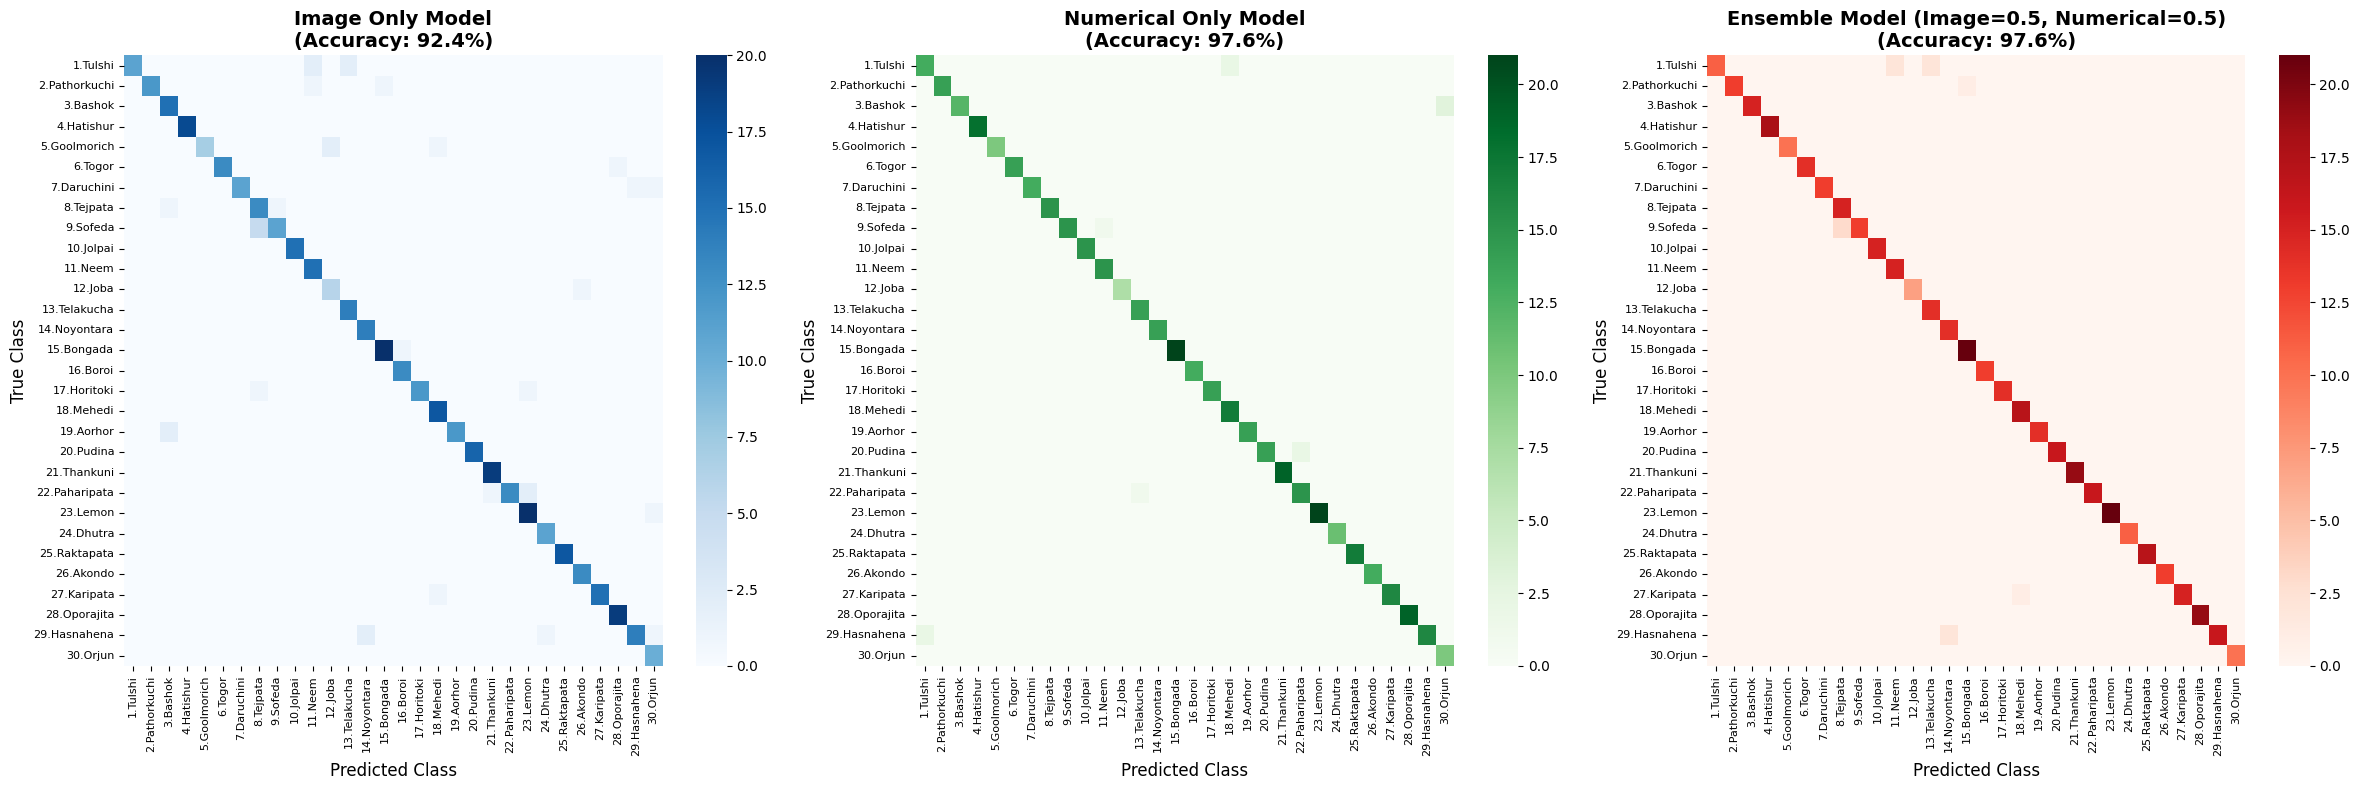


📊 DETAILED CLASSIFICATION REPORT - ENSEMBLE MODEL
               precision    recall  f1-score   support

     1.Tulshi      1.000     0.733     0.846        15
2.Pathorkuchi      1.000     0.929     0.963        14
     3.Bashok      1.000     1.000     1.000        15
   4.Hatishur      1.000     1.000     1.000        18
 5.Goolmorich      1.000     1.000     1.000        10
      6.Togor      1.000     1.000     1.000        14
  7.Daruchini      1.000     1.000     1.000        13
    8.Tejpata      0.833     1.000     0.909        15
     9.Sofeda      1.000     0.812     0.897        16
    10.Jolpai      1.000     1.000     1.000        15
      11.Neem      0.882     1.000     0.938        15
      12.Joba      1.000     1.000     1.000         7
 13.Telakucha      0.875     1.000     0.933        14
 14.Noyontara      0.875     1.000     0.933        14
   15.Bongada      0.955     1.000     0.977        21
     16.Boroi      1.000     1.000     1.000        13
  17.Horitoki

In [11]:
# ============================================
# CELL 11: Confusion Matrix for Ensemble Model
# ============================================
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrices(image_model, numerical_model, test_loader):
    """Plot confusion matrices for all three models"""

    image_model.eval()

    # Store predictions
    all_ensemble_preds = []
    all_image_preds = []
    all_numerical_preds = []
    all_labels = []

    print("📊 Generating predictions for confusion matrices...")

    with torch.no_grad():
        for images, numerical_feats, labels in tqdm(test_loader, desc="Processing"):
            images = images.to(config.DEVICE)

            # Image model predictions
            image_outputs = image_model(images)
            image_probs = torch.softmax(image_outputs, dim=1).cpu().numpy()

            # Random Forest predictions (or MLP)
            if isinstance(numerical_model, NumericalRandomForest):
                numerical_probs = numerical_model.predict_proba(numerical_feats.numpy())
            else:
                numerical_outputs = numerical_model(numerical_feats.to(config.DEVICE))
                numerical_probs = torch.softmax(numerical_outputs, dim=1).cpu().numpy()

            # Ensemble (weighted average)
            ensemble_probs = (config.IMAGE_WEIGHT * image_probs +
                             config.NUMERICAL_WEIGHT * numerical_probs)
            ensemble_preds = np.argmax(ensemble_probs, axis=1)

            # Individual predictions
            image_preds = np.argmax(image_probs, axis=1)
            numerical_preds = np.argmax(numerical_probs, axis=1)

            all_ensemble_preds.extend(ensemble_preds)
            all_image_preds.extend(image_preds)
            all_numerical_preds.extend(numerical_preds)
            all_labels.extend(labels.numpy())

    # Get class names
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    # Create confusion matrices
    cm_ensemble = confusion_matrix(all_labels, all_ensemble_preds)
    cm_image = confusion_matrix(all_labels, all_image_preds)
    cm_numerical = confusion_matrix(all_labels, all_numerical_preds)

    # Plot all three confusion matrices
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # 1. Image Model Confusion Matrix
    sns.heatmap(cm_image, annot=False, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], cbar=True)
    axes[0].set_title(f'Image Only Model\n(Accuracy: {np.trace(cm_image)/np.sum(cm_image)*100:.1f}%)',
                      fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Predicted Class', fontsize=12)
    axes[0].set_ylabel('True Class', fontsize=12)
    axes[0].tick_params(axis='x', rotation=90, labelsize=8)
    axes[0].tick_params(axis='y', labelsize=8)

    # 2. Numerical Model Confusion Matrix
    sns.heatmap(cm_numerical, annot=False, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], cbar=True)
    axes[1].set_title(f'Numerical Only Model\n(Accuracy: {np.trace(cm_numerical)/np.sum(cm_numerical)*100:.1f}%)',
                      fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Predicted Class', fontsize=12)
    axes[1].set_ylabel('True Class', fontsize=12)
    axes[1].tick_params(axis='x', rotation=90, labelsize=8)
    axes[1].tick_params(axis='y', labelsize=8)

    # 3. Ensemble Confusion Matrix
    sns.heatmap(cm_ensemble, annot=False, fmt='d', cmap='Reds',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[2], cbar=True)
    axes[2].set_title(f'Ensemble Model (Image={config.IMAGE_WEIGHT}, Numerical={config.NUMERICAL_WEIGHT})\n(Accuracy: {np.trace(cm_ensemble)/np.sum(cm_ensemble)*100:.1f}%)',
                      fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Predicted Class', fontsize=12)
    axes[2].set_ylabel('True Class', fontsize=12)
    axes[2].tick_params(axis='x', rotation=90, labelsize=8)
    axes[2].tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(config.SAVE_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Print detailed classification report
    print("\n" + "="*80)
    print("📊 DETAILED CLASSIFICATION REPORT - ENSEMBLE MODEL")
    print("="*80)
    print(classification_report(all_labels, all_ensemble_preds,
                                target_names=class_names, digits=3))

    # Per-class accuracy (calculated before modifying cm_ensemble for confused pairs)
    print("\n📈 PER-CLASS ACCURACY:")
    print("-"*80)
    for i, class_name in enumerate(class_names):
        correct = cm_ensemble[i, i]
        total = np.sum(cm_ensemble[i, :])
        acc = correct / total * 100 if total > 0 else 0
        bar_length = int(acc / 2)
        bar = "█" * bar_length + "░" * (50 - bar_length) # Use 50 as max bar length
        print(f"{class_name:20} {bar} {acc:5.1f}%")

    # Find most confused classes
    print("\n" + "="*80)
    print("🔍 MOST CONFUSED CLASS PAIRS")
    print("="*80)

    # Create a copy of cm_ensemble to zero out diagonal for confused pairs
    cm_ensemble_for_confused_pairs = cm_ensemble.copy()
    np.fill_diagonal(cm_ensemble_for_confused_pairs, 0) # Zero out diagonal for finding max off-diagonal

    max_confusion_idx = np.unravel_index(np.argmax(cm_ensemble_for_confused_pairs), cm_ensemble_for_confused_pairs.shape)
    print(f"Most confused pair: {class_names[max_confusion_idx[0]]} ↔ {class_names[max_confusion_idx[1]]}")
    print(f"  (True: {class_names[max_confusion_idx[0]]}, Predicted as: {class_names[max_confusion_idx[1]]})")

    return cm_ensemble, cm_image, cm_numerical

# Plot confusion matrices
cm_ensemble, cm_image, cm_numerical = plot_confusion_matrices(
    image_model, numerical_model, test_loader
)

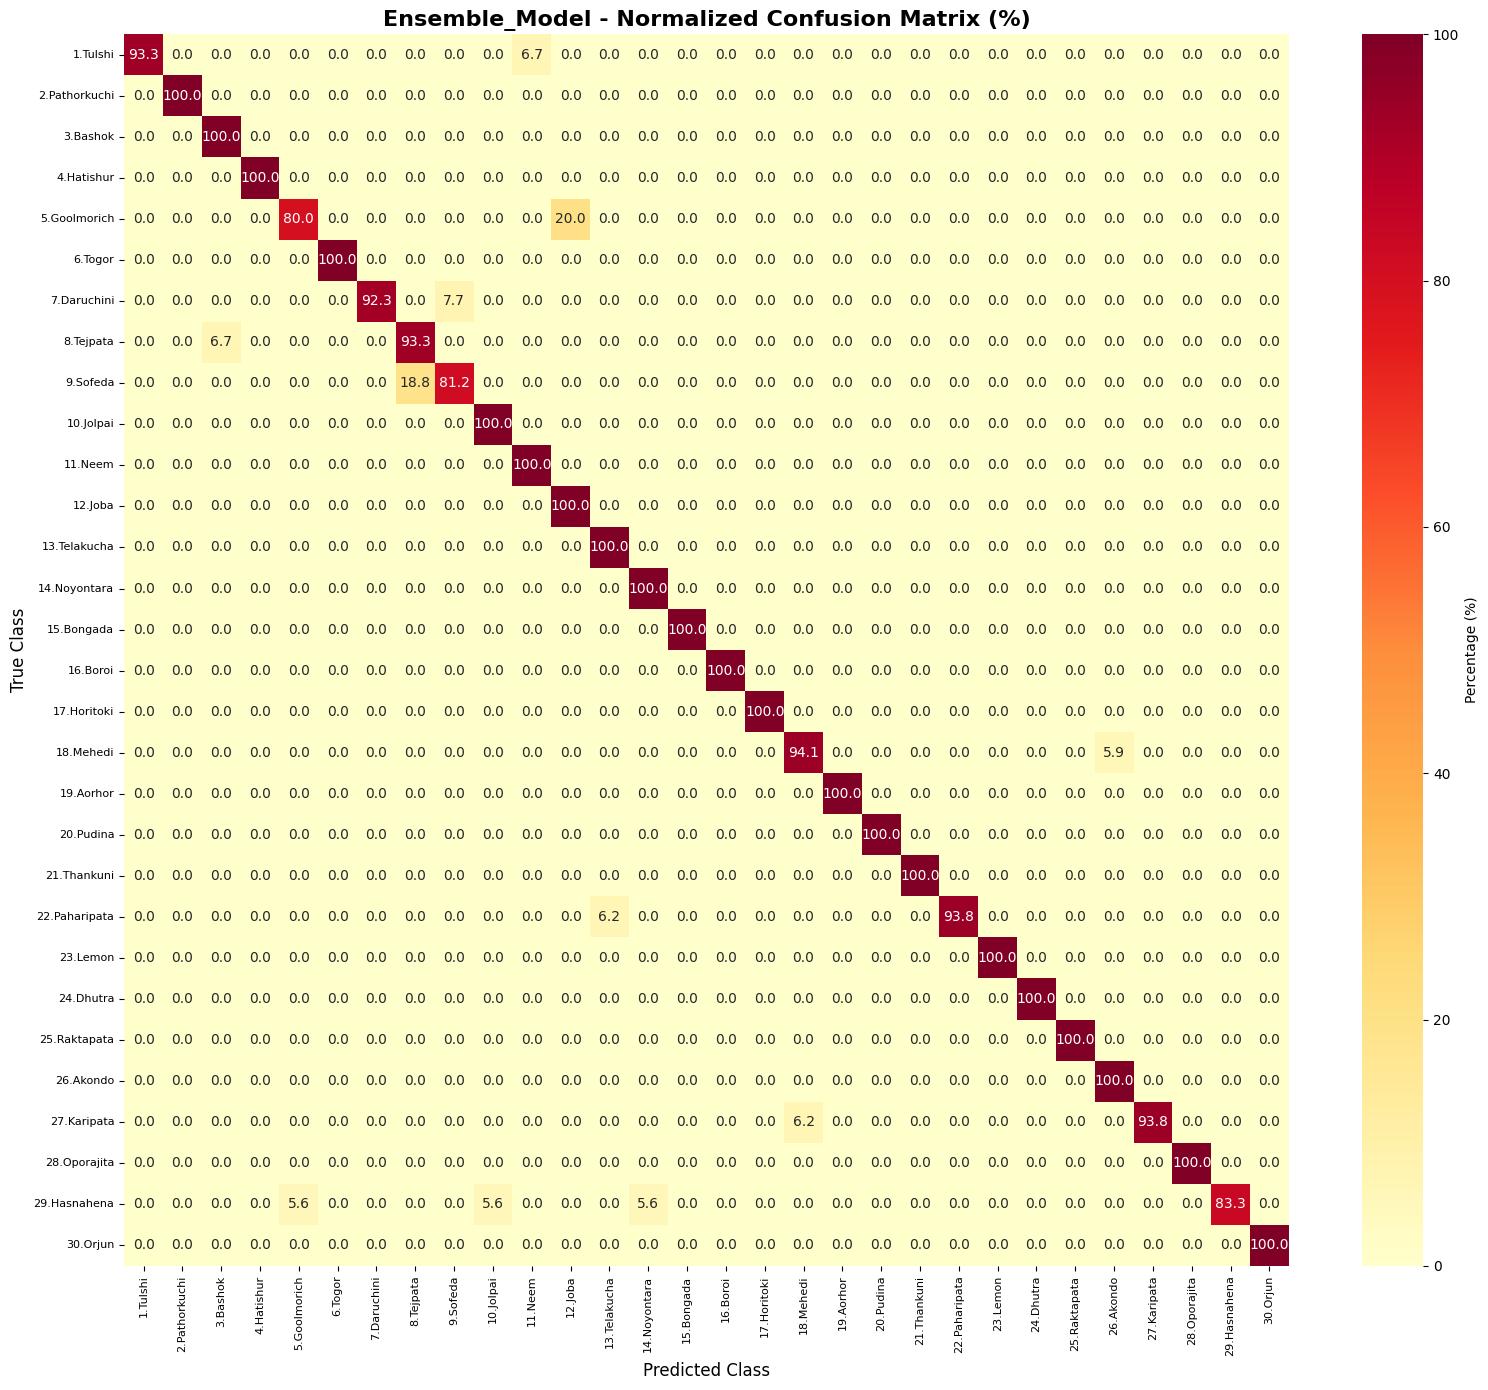

In [12]:
# ============================================
# CELL 12: Normalized Confusion Matrix (Percentages)
# ============================================
def plot_normalized_confusion_matrix(model_type, predictions, labels, class_names):
    """Plot normalized confusion matrix (percentages)"""

    cm = confusion_matrix(labels, predictions)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(16, 14))
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=class_names, yticklabels=class_names,
                vmin=0, vmax=100, cbar_kws={'label': 'Percentage (%)'})
    plt.title(f'{model_type} - Normalized Confusion Matrix (%)', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Class', fontsize=12)
    plt.ylabel('True Class', fontsize=12)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(config.SAVE_DIR, f'{model_type}_normalized_cm.png'), dpi=150)
    plt.show()

# Get class names
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

# Get predictions again (if needed)
image_model.eval()
all_ensemble_preds = []
all_labels = []

with torch.no_grad():
    for images, numerical_feats, labels in test_loader:
        images = images.to(config.DEVICE)
        image_outputs = image_model(images)
        image_probs = torch.softmax(image_outputs, dim=1).cpu().numpy()

        if isinstance(numerical_model, NumericalRandomForest):
            numerical_probs = numerical_model.predict_proba(numerical_feats.numpy())
        else:
            numerical_outputs = numerical_model(numerical_feats.to(config.DEVICE))
            numerical_probs = torch.softmax(numerical_outputs, dim=1).cpu().numpy()

        ensemble_probs = (config.IMAGE_WEIGHT * image_probs + config.NUMERICAL_WEIGHT * numerical_probs)
        ensemble_preds = np.argmax(ensemble_probs, axis=1)

        all_ensemble_preds.extend(ensemble_preds)
        all_labels.extend(labels.numpy())

# Plot normalized confusion matrix for ensemble
plot_normalized_confusion_matrix('Ensemble_Model', all_ensemble_preds, all_labels, class_names)

In [13]:
# ============================================
# CELL 13: Performance Summary Table
# ============================================
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

def create_performance_table(image_model, numerical_model, test_loader):
    """Create detailed performance table"""

    image_model.eval()

    all_ensemble_preds = []
    all_image_preds = []
    all_numerical_preds = []
    all_labels = []

    with torch.no_grad():
        for images, numerical_feats, labels in test_loader:
            images = images.to(config.DEVICE)
            image_outputs = image_model(images)
            image_probs = torch.softmax(image_outputs, dim=1).cpu().numpy()

            if isinstance(numerical_model, NumericalRandomForest):
                numerical_probs = numerical_model.predict_proba(numerical_feats.numpy())
            else:
                numerical_outputs = numerical_model(numerical_feats.to(config.DEVICE))
                numerical_probs = torch.softmax(numerical_outputs, dim=1).cpu().numpy()

            ensemble_probs = (config.IMAGE_WEIGHT * image_probs +
                            config.NUMERICAL_WEIGHT * numerical_probs)
            ensemble_preds = np.argmax(ensemble_probs, axis=1)

            all_ensemble_preds.extend(ensemble_preds)
            all_image_preds.extend(np.argmax(image_probs, axis=1))
            all_numerical_preds.extend(np.argmax(numerical_probs, axis=1))
            all_labels.extend(labels.numpy())

    # Calculate metrics
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    # Per-class metrics for ensemble
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_ensemble_preds, average=None
    )

    # Create DataFrame
    df = pd.DataFrame({
        'Species': class_names,
        'Precision (%)': precision * 100,
        'Recall (%)': recall * 100,
        'F1-Score (%)': f1 * 100,
        'Samples': support
    })

    # Overall accuracy
    ensemble_acc = accuracy_score(all_labels, all_ensemble_preds) * 100
    image_acc = accuracy_score(all_labels, all_image_preds) * 100
    numerical_acc = accuracy_score(all_labels, all_numerical_preds) * 100

    print("\n" + "="*80)
    print("📊 DETAILED CLASSIFICATION REPORT - ENSEMBLE MODEL")
    print("="*80)
    print(classification_report(all_labels, all_ensemble_preds,digits=3))



    # Display
    print("\n" + "="*80)
    print("📊 PER-CLASS PERFORMANCE - ENSEMBLE MODEL")
    print("="*80)
    print(df.to_string(index=False))

    print("\n" + "="*80)
    print("📊 OVERALL PERFORMANCE SUMMARY")
    print("="*80)
    print(f"{'Model':<30} {'Accuracy':<15} {'vs Ensemble':<15}")
    print("-"*60)
    print(f"{'Image Only Model':<30} {image_acc:>6.2f}%    {'':<15}")
    print(f"{'Numerical Only Model':<30} {numerical_acc:>6.2f}%    {'':<15}")
    print(f"{'Ensemble Model':<30} {ensemble_acc:>6.2f}%    {'(Baseline)':<15}")
    print(f"\n✅ Ensemble Improvement over Image: {ensemble_acc - image_acc:+.2f}%")
    print(f"✅ Ensemble Improvement over Numerical: {ensemble_acc - numerical_acc:+.2f}%")

    # Save to CSV
    df.to_csv(os.path.join(config.SAVE_DIR, 'per_class_performance.csv'), index=False)
    print(f"\n📁 Detailed report saved to: {config.SAVE_DIR}/per_class_performance.csv")

    return df

# Create performance table
performance_df = create_performance_table(image_model, numerical_model, test_loader)


📊 DETAILED CLASSIFICATION REPORT - ENSEMBLE MODEL
              precision    recall  f1-score   support

           0      1.000     0.933     0.966        15
           1      1.000     0.929     0.963        14
           2      1.000     1.000     1.000        15
           3      1.000     0.944     0.971        18
           4      1.000     1.000     1.000        10
           5      1.000     1.000     1.000        14
           6      1.000     1.000     1.000        13
           7      0.875     0.933     0.903        15
           8      0.933     0.875     0.903        16
           9      1.000     1.000     1.000        15
          10      0.938     1.000     0.968        15
          11      1.000     1.000     1.000         7
          12      0.875     1.000     0.933        14
          13      0.875     1.000     0.933        14
          14      0.952     0.952     0.952        21
          15      1.000     1.000     1.000        13
          16      1.000     1.

In [ ]:
# ============================================
# DIAGNOSTIC CELL: Check model predictions
# ============================================
print("🔍 DIAGNOSING MODEL ISSUES")
print("="*60)

# Check 1: Are model weights loaded?
image_model.eval()
with torch.no_grad():
    # Get a single batch
    for images, numerical_feats, labels in test_loader:
        images = images.to(config.DEVICE)
        outputs = image_model(images)
        preds = torch.argmax(outputs, dim=1)

        print(f"\n✓ Model is producing predictions")
        print(f"   Output shape: {outputs.shape}")
        print(f"   Prediction range: {preds.min().item()} to {preds.max().item()}")
        print(f"   Unique predictions: {torch.unique(preds).tolist()}")
        print(f"   First 10 predictions: {preds[:10].tolist()}")
        print(f"   First 10 true labels: {labels[:10].tolist()}")

        # Check if all predictions are same
        if len(torch.unique(preds)) == 1:
            print(f"\n❌ PROBLEM: Model predicts ONLY class {preds[0].item()} for all samples!")
        else:
            print(f"\n✅ Model is predicting multiple classes")
        break

🔍 DIAGNOSING MODEL ISSUES

✓ Model is producing predictions
   Output shape: torch.Size([64, 30])
   Prediction range: 1 to 29
   Unique predictions: [1, 2, 3, 4, 5, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
   First 10 predictions: [14, 3, 29, 13, 27, 28, 12, 5, 9, 3]
   First 10 true labels: [14, 3, 29, 13, 27, 28, 12, 5, 22, 3]

✅ Model is predicting multiple classes
